# Notebook to fit mocks:

**Remark:** 
 * I work in my local branch of `desi-clustering`: `edmond-dev`
 * For now it turns with `desilike/dr2-dev`

In [1]:
import logging

import os
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
import functools

import numpy as np
import matplotlib.pyplot as plt

logger = logging.getLogger('FIT PNG')

# remove warning on my mac -> deactivate on NERSC.
os.environ['OMPI_MCA_btl'] = 'self,tcp'  # deactivate shmem

plt.style.use('ec_style.mplstyle')   

# # disable jax warning:
# logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
# logging.getLogger("jax._src.distributed").setLevel(logging.ERROR)
# # Remove warning from jax
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [2]:
def plot_corr(cov, fn=None): 
    import matplotlib.text
    import re
    
    fig = cov.plot(corrcoef=True, figsize=(9,9))
    for txt in fig.findobj(matplotlib.text.Text):
        s = txt.get_text()
        s = s.replace('spectrum2,', '').replace(',spectrum2', '').replace('spectrum2', '')
        s = re.sub(r'\b(\w+)_\1\b', r'\1', s)   # LRG_LRG -> LRG
        s = s.replace('_', 'x')                 # LRG_QSO -> LRGxQSO
        s = s.replace('\nx ', '\n')             # remove "x " prefix on second line
        if '\n' in s: txt.set_fontsize(8)
        txt.set_text(s)
    if fn is not None: plt.savefig(fn)
    plt.show()


def propose_fiducial(kmin=1e-3):
    """ 
    """
    propose_fiducial = {}

    propose_fiducial['LRG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.4, 1.1), 'region': 'GCcomb', 
                               'use_ell2': True, 'kmin': kmin, 'kmax': 0.08, 'kmin_ell2': kmin, 'kmax_ell2': 0.08}
    propose_fiducial['ELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': 'GCcomb', 
                               'use_ell2': True, 'kmin': kmin, 'kmax': 0.08, 'kmin_ell2': kmin, 'kmax_ell2': 0.08}  #6e-3
    propose_fiducial['QSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 3.5), 'region': 'GCcomb', 
                               'use_ell2': True, 'kmin': kmin, 'kmax': 0.08, 'kmin_ell2': kmin, 'kmax_ell2': 0.08}   
    
    propose_fiducial['LRGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': 'GCcomb', 
                                   'use_ell2': True, 'kmin': kmin, 'kmax': 0.08, 'kmin_ell2': kmin, 'kmax_ell2': 0.08}   
    propose_fiducial['LRGxELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': 'GCcomb', 
                                   'use_ell2': True, 'kmin': kmin, 'kmax': 0.08, 'kmin_ell2': kmin, 'kmax_ell2': 0.08}   
    propose_fiducial['ELGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': 'GCcomb', 
                                   'use_ell2': True, 'kmin': kmin, 'kmax': 0.08, 'kmin_ell2': kmin, 'kmax_ell2': 0.08}   
    
    # when sort tracer name, ELG arrive first, so it is convienient to have it here as well 
    propose_fiducial['ELGxLRG'] = propose_fiducial['LRGxELG']
      
    return propose_fiducial


def load_data(data_dir, mocks_dir, tracers_to_read, fiducial=propose_fiducial(), add_ic=True, aladr1=True, nmocks_mean=None):
    """ 
    """
    from clustering_statistics.tools import get_stats_fn
    import lsstypes 

    from tools import read_data, rebin_data

    pks, windows, covs, zeffs, mocks, mean_mocks = {}, {}, {}, {}, {}, {}
    for tracer in tracers_to_read:
        short_tracer = tracer.replace('_zcmb', '')
        short_tracer = short_tracer.replace('notqso', '')

        weight_type_mocks = 'default-fkp-oqe' if add_ic else 'default-noimsys-fkp-oqe_reshuffle'

        pk, window, cov, mock = read_data(data_dir=data_dir, mocks_dir=mocks_dir, tracer=tracer, 
                                           add_ic=add_ic, aladr1=aladr1, weight_type_mocks=weight_type_mocks, **fiducial[short_tracer])
        pk, window, cov, mock = rebin_data(pk, window, cov, mock, tracer=tracer, **fiducial[short_tracer])
        try: 
            logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} and {pk.get(2).k.shape[0]} data points.')
        except KeyError:
            logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} data points.')
    
        if 'x' not in short_tracer: short_tracer = 'x'.join(2*[short_tracer])
        pks[short_tracer], windows[short_tracer], covs[short_tracer], mocks[short_tracer] = pk, window, cov, mock

        if nmocks_mean is not None:
            # Keep only mocks that are not used in the mean, to have independent mocks for covariance validation and likelihood profiling.
            mean_mocks[short_tracer] = lsstypes.mean(mocks[short_tracer][:nmocks_mean])
            mocks[short_tracer] = mocks[short_tracer][nmocks_mean:]

        zeffs[short_tracer] = {}
        zeffs[short_tracer][0] = windows[short_tracer].observable.get(0).attrs['zeff']
        try: 
            zeffs[short_tracer][2] = windows[short_tracer].observable.get(2).attrs['zeff']
        except KeyError:
            pass

    if nmocks_mean is not None:
        return pks, windows, covs, zeffs, mocks, mean_mocks 
    else:
        return pks, windows, covs, zeffs, mocks


# Fit the mean of 100 Mocks:

In [27]:
from tools import get_observable_and_likelihood, build_total_likelihood, plot_observables, run_profiler, run_mcmc, plot_triangle

# Where the data are:
data_dir = '/Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded/'

# Where the mocks are:
mocks_dir = '/Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/'

fiducial = propose_fiducial(kmin=1e-3)  
tracers_to_read = ['LRG', 'QSO', 'ELGnotqso', 'LRGxQSO', 'LRGxELGnotqso', 'ELGnotqsoxQSO'][:3]
nmocks_mean = 100

pks, windows, covs, zeffs, mocks, mean_mocks = load_data(data_dir, mocks_dir, tracers_to_read, fiducial, add_ic=True, aladr1=False, nmocks_mean=nmocks_mean)

_, windows_aladr1, _, _, _, = load_data(data_dir, mocks_dir, tracers_to_read, fiducial, add_ic=True, aladr1=True)

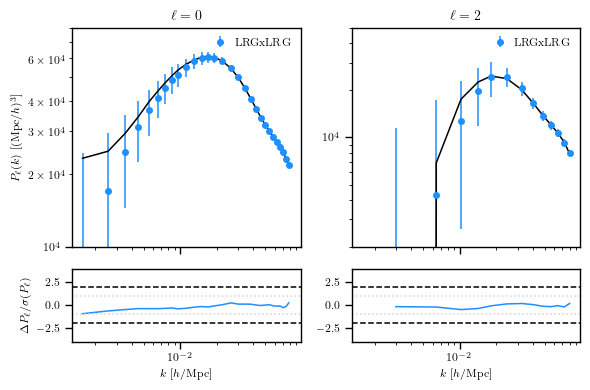

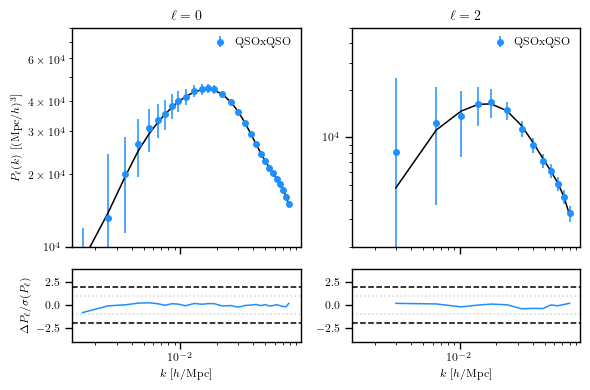

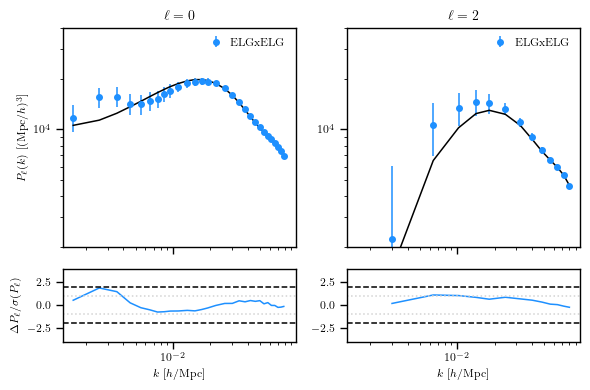

In [28]:
tracers = ['LRGxLRG', 'QSOxQSO', 'ELGxELG', 'LRGxELG', 'LRGxQSO', 'ELGxQSO'][:3]

# just to have a coherent value of b1 in the cross correlation.
kwargs = {'LRG_LRGxQSO_ell0.b1': 2.15, 'LRG_LRGxELG_ell0.b1': 2.15,  'ELG_ELGxQSO_ell0.b1': 1.2, 'scale_covariance': 1} 

observables, likelihoods, profilers = {}, {}, {}

for analytical_covariance in [False, True]:
    for tracer in tracers:
        covariance = covs[tracer] if analytical_covariance else mocks[tracer]
        tracer_to_save = tracer + ('' if analytical_covariance else '_mock_cov')
        observables[tracer], likelihoods[tracer_to_save] = get_observable_and_likelihood(mean_mocks[tracer], windows[tracer], covariance, tracer, zeffs, 
                                                                                engine='camb', fix_fnl=False, nickname=tracer, **kwargs)
        
        fn_profile = mocks_dir.replace('summary_statistics', 'profiles') + f"holi-v3-altmtl/mean/bestfit_{tracer}_mean-{nmocks_mean}{'_analytical_cov' if analytical_covariance else '_mock_cov'}_fiducial.npy"
        profilers[tracer_to_save] = run_profiler(likelihoods[tracer_to_save]) # DO not do what I WANT FOR NOW, fn_output=fn_profile)

for tracer in tracers:
    ylims = [(2e3, 4e4), (2e3, 4e4)] if tracer in ['ELGxELG', 'ELGxQSO'] else None
    plot_observables({tracer: observables[tracer]}, ylims=ylims)

orders = [['LRGxLRG', 'QSOxQSO', 'LRGxQSO'], ['LRGxLRG', 'ELGxELG', 'LRGxELG'], ['ELGxELG', 'QSOxQSO', 'ELGxQSO']]
orders += [['LRGxLRG', 'ELGxELG','QSOxQSO', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']]

orders = []

for analytical_covariance in [False, True]:
    for order in orders:
        tracer_to_save = '-'.join(order) + ('' if analytical_covariance else '_mock_cov')
        likelihoods[tracer_to_save] = build_total_likelihood(order, mean_mocks, observables, covs if analytical_covariance else mocks, zeffs, fiducial)
        
        fn_profile = mocks_dir.replace('summary_statistics', 'profiles') + f"holi-v3-altmtl/mean/bestfit_{'-'.join(order)}_mean-{nmocks_mean}{'_analytical_cov' if analytical_covariance else '_mock_cov'}_fiducial.npy"
        profilers[tracer_to_save] = run_profiler(likelihoods[tracer_to_save]) # DO not do what I WANT FOR NOW, fn_output=fn_profile)

In [30]:
from tabulate import tabulate

for tracer in tracers:
    params, _ = profilers[tracer].profiles.to_stats(tablefmt="list")
    params2, _ = profilers[f'{tracer}_mock_cov'].profiles.to_stats(tablefmt="list")
    for i in range(len(params)):
        params[i] = [params[i][0]] + params[i][2:4] + params2[i][2:4]
    print(tabulate(params, headers=[tracer, 'bestfit (analytic)', 'error (analytic)', 'bestfit (mock)', 'error (mock)'], tablefmt='pretty'))

for order in orders:
    tracer = '-'.join(order)
    params, _ = profilers[tracer].profiles.to_stats(tablefmt="list")
    params2, _ = profilers[f'{tracer}_mock_cov'].profiles.to_stats(tablefmt="list")
    to_display = []
    for i in range(len(params)):
        if params[i][3] == '':
            pass
        else:
            to_display.append([params[i][0]] + params[i][2:4] + params2[i][2:4])
    print(tabulate(to_display, headers=[tracer, 'bestfit (analytic)', 'error (analytic)', 'bestfit (mock)', 'error (mock)'], tablefmt='pretty'))

+-----------------+--------------------+------------------+----------------+--------------+
|     LRGxLRG     | bestfit (analytic) | error (analytic) | bestfit (mock) | error (mock) |
+-----------------+--------------------+------------------+----------------+--------------+
|     fnl_loc     |        -7.4        |       6.7        |      -5.4      |     3.1      |
|  LRG_ell0.sn0   |       0.029        |      0.051       |     0.029      |    0.052     |
|   LRG_ell0.b1   |       2.159        |      0.026       |     2.158      |    0.026     |
| LRG_ell0.sigmas |        3.97        |       0.34       |      3.97      |     0.37     |
|   LRG_ell2.b1   |        2.2         |                  |      2.2       |              |
| LRG_ell2.sigmas |        4.0         |                  |      4.0       |              |
+-----------------+--------------------+------------------+----------------+--------------+
+-----------------+--------------------+------------------+----------------+----

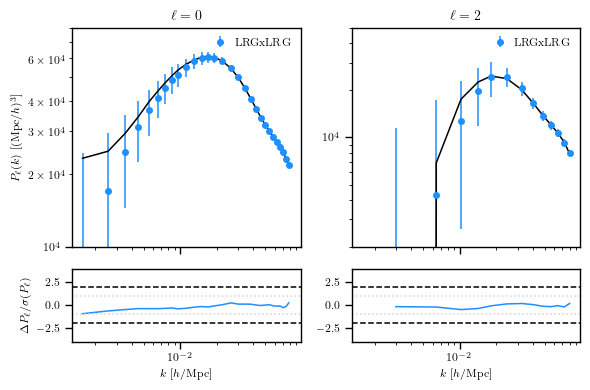

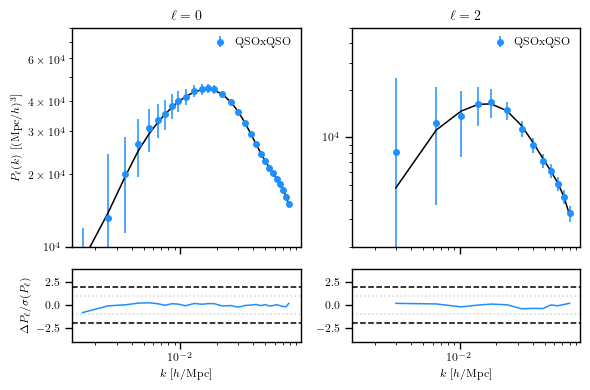

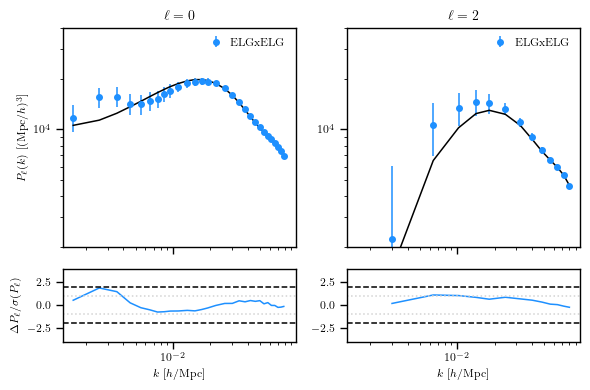

+------------------------------------+--------+---------+-------+
| chi2 / (42 - 4) = 3.94 / 38 = 0.10 | varied | bestfit | error |
+------------------------------------+--------+---------+-------+
|              fnl_loc               |  True  |  -4.8   |  3.9  |
|            LRG_ell0.sn0            |  True  |  0.025  | 0.052 |
|            LRG_ell0.b1             |  True  |  2.161  | 0.026 |
|          LRG_ell0.sigmas           |  True  |  4.05   | 0.36  |
|            LRG_ell2.b1             |  True  |   2.2   |       |
|          LRG_ell2.sigmas           |  True  |   4.0   |       |
+------------------------------------+--------+---------+-------+
+------------------------------------+--------+---------+-------+
| chi2 / (42 - 4) = 1.73 / 38 = 0.05 | varied | bestfit | error |
+------------------------------------+--------+---------+-------+
|              fnl_loc               |  True  |  -1.6   |  4.0  |
|            QSO_ell0.sn0            |  True  | -0.057  | 0.047 |
|         

In [35]:
observables_aladr1, likelihoods_aladr1, profilers_aladr1 = {}, {}, {}

for analytical_covariance in [False]:
    for tracer in tracers:
        covariance = covs[tracer] if analytical_covariance else mocks[tracer]
        tracer_to_save = tracer + ('' if analytical_covariance else '_mock_cov')
        observables_aladr1[tracer], likelihoods_aladr1[tracer_to_save] = get_observable_and_likelihood(mean_mocks[tracer], windows_aladr1[tracer], covariance, tracer, zeffs, 
                                                                                engine='camb', fix_fnl=False, nickname=tracer, **kwargs)
        
        fn_profile = mocks_dir.replace('summary_statistics', 'profiles') + f"holi-v3-altmtl/mean/bestfit_{tracer}_mean-{nmocks_mean}{'_analytical_cov' if analytical_covariance else '_mock_cov'}_fiducial_aladr1.npy"
        profilers_aladr1[tracer_to_save] = run_profiler(likelihoods_aladr1[tracer_to_save]) # DO not do what I WANT FOR NOW, fn_output=fn_profile)

for tracer in tracers:
    ylims = [(2e3, 4e4), (2e3, 4e4)] if tracer in ['ELGxELG', 'ELGxQSO'] else None
    plot_observables({tracer: observables[tracer]}, ylims=ylims)

for tracer in tracers:
    print(profilers_aladr1[tracer+'_mock_cov'].profiles.to_stats(tablefmt="pretty"))

In [ ]:
pdf_path = Path('fig/fit_mocks_error_fnl.pdf')

with PdfPages(pdf_path) as pdf:

    for tracer in tracers:
        to_plot = []

        for kmin in [1e-3 + i*1e-3 for i in range(10)]:

            pk = mean_mocks[tracer].select(k=(kmin, 1))
            window = windows[tracer].at.observable.match(pk)
            covariance = covs[tracer].at.observable.at(observables='spectrum2', tracers=tuple(tracer.split("x"))).match(pk)

            _, lik = get_observable_and_likelihood(pk, window, covariance, tracer, zeffs, 
                                                    engine='camb', fix_fnl=False, nickname=tracer, **kwargs)
            profile = run_profiler(lik).profiles.choice()
            fnl, err_fnl = profile.bestfit['fnl_loc'].value[0], profile.error['fnl_loc'].value[0]
            cov_inv_correction = 1 #len(mocks[tracer])
            chi2_red = -2. * profile.bestfit['logposterior'].value[0] / (lik.data.size - len(lik.varied_params)) * cov_inv_correction

            covariance = [mm.match(pk) for mm in mocks[tracer]]
            _, lik = get_observable_and_likelihood(pk, window, covariance, tracer, zeffs, 
                                                    engine='camb', fix_fnl=False, nickname=tracer, **kwargs)
            profile = run_profiler(lik).profiles.choice()
            fnl_mock_cov, err_fnl_mock_cov = profile.bestfit['fnl_loc'].value[0], profile.error['fnl_loc'].value[0]
            # Don't forget to remove the percival factor when computing the chi2_red
            cov_inv_correction = 1 / lik.percival2014_factor  # len(mocks[tracer])
            chi2_red_mock_cov = -2. * profile.bestfit['logposterior'].value[0] / (lik.data.size - len(lik.varied_params)) * cov_inv_correction

            to_plot.append((kmin, float(fnl), float(err_fnl), float(chi2_red), float(fnl_mock_cov), float(err_fnl_mock_cov), float(chi2_red_mock_cov)))

        to_plot = np.array(to_plot)

        plt.figure(figsize=(7,2.5))
        plt.subplot(131)
        plt.errorbar(to_plot[:,0], to_plot[:,1], yerr=to_plot[:,2], marker='o', ls='', label=tracer)
        plt.errorbar(to_plot[:,0], to_plot[:,4], yerr=to_plot[:,5], marker='d', ls='')
        plt.axhline(0, c='k', ls='--', zorder=-1)
        plt.xlabel(r'$k_\mathrm{min}$ [$h/\mathrm{Mpc}$]')
        plt.ylabel(r'$f_\mathrm{NL}^\mathrm{loc}$')
        plt.legend()

        plt.subplot(132)
        plt.plot(to_plot[:,0], to_plot[:,2], ls='-', label='analytic cov')
        plt.plot(to_plot[:,0], to_plot[:,5], ls='--', label='mock cov')
        plt.xlabel(r'$k_\mathrm{min}$ [$h/\mathrm{Mpc}$]')
        plt.ylabel(r'$\sigma(f_\mathrm{NL}^\mathrm{loc})$')
        plt.ylim([0, 40])
        plt.legend()

        plt.subplot(133)
        plt.plot(to_plot[:,0], to_plot[:,3], ls='-', label='analytic cov')
        plt.plot(to_plot[:,0], to_plot[:,6], ls='--', label='mock cov')
        plt.xlabel(r'$k_\mathrm{min}$ [$h/\mathrm{Mpc}$]')
        plt.ylabel(r'$\chi^2_{\mathrm{red}}$')
        plt.ylim([0, 1])
        plt.legend()
        plt.tight_layout()
        pdf.savefig(plt.gcf())
        plt.show()

    pdf_path.resolve()

In [ ]:
# samplers = {}
# for tracer in tracers:
#     print(f'Run MCMC for {tracer=}:')
#     samplers[tracer] =  run_mcmc(likelihoods[tracer], max_iterations=20000, check_every=5000)

# from desilike.samples import Chain

# #chains = Chain.concatenate([Chain.load(fn_chains[key].replace('*', str(i))).remove_burnin(burnin)[::thin] for i in range(nchains)])

# burnin, thin = 0.3, 10
# chains = {}
# for tracer in samplers.keys():
#      chains[tracer] = Chain.concatenate([chain.remove_burnin(burnin)[::thin] for chain in samplers[tracer].chains])

# for tracer in chains.keys():
#     print(f'Best fit for {tracer=}: ({chains[tracer]["fnl_loc"].size} points)')
#     print(chains[tracer].to_stats(tablefmt="pretty"))

# for tracer in chains.keys():
#     params = likelihoods[tracer].varied_params
#     plot_triangle(chains[tracer], params, legend_labels=[tracer])

# plot_triangle([chains[tracer] for tracer in chains.keys()], ['fnl_loc'], legend_labels=list(chains.keys()), xlabels=[r'$f_{\rm NL}^{\rm loc}$'], 
#               filled=[True]*len(chains), contour_colors=['C0', 'C1', 'C2'], contour_ls=['-', '-', '-'])

# Fit each individual mocks:

In [3]:
import itertools
import tqdm
from concurrent.futures import ProcessPoolExecutor

from tools import run_profiling_one_mock

In [4]:
import os
import re
from pathlib import Path
from collections import defaultdict

def load_all_profiles(mocks_dir):
    """
    Load all profile .npy files from the holi-v3-altmtl/mock* directories
    and organize them in a nested dictionary structure.
    
    Handles filenames with optional suffixes:
    - bestfit_{tracer}_{cov_type}_kmin-{kmin}.npy
    - bestfit_{tracer}_{cov_type}_kmin-{kmin}_{any_suffix}.npy
    
    Returns:
        profiles: dict with structure {tracer: {cov_type: {kmin: {suffix: {imock: array}}}}}
        where suffix is '' (no suffix) or '_something'
    """
    base_dir = Path(mocks_dir.replace('summary_statistics', 'profiles')) / 'holi-v3-altmtl'
    
    # Initialize nested dictionary
    profiles = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(dict))))
    
    # Pattern to parse filenames: captures optional suffix starting with underscore
    pattern = r'bestfit_(.+?)_(analytical_cov|mock_cov)_kmin-([0-9e\-\.]+)(_.*)?\.npy'
    
    # Iterate through all mock directories
    mock_dirs = sorted(base_dir.glob('mock*'), key=lambda x: int(x.name.replace('mock', '')))
    
    for mock_dir in mock_dirs:
        if not mock_dir.is_dir():
            continue
        
        imock = int(mock_dir.name.replace('mock', ''))
        
        # Find all .npy files in this mock directory
        for npy_file in sorted(mock_dir.glob('bestfit_*.npy')):
            match = re.match(pattern, npy_file.name)
            if match:
                tracer, cov_type, kmin, suffix = match.groups()
                kmin = float(kmin)
                suffix = suffix if suffix else ''  # Use empty string if no suffix
                
                # Load the file
                profiles[tracer][cov_type][kmin][suffix][imock] = np.load(str(npy_file))
    
    # Convert defaultdict to regular dict for cleaner output
    profiles = {k: {k2: {k3: {k4: dict(v4) for k4, v4 in v3.items()} for k3, v3 in v2.items()} for k2, v2 in v.items()} 
                for k, v in profiles.items()}
    
    return profiles

def summary_profiles(profiles):
    """ Generate a summary DataFrame of the loaded profiles, showing the number of mocks and range of mock 
        indices for each tracer, covariance type, kmin, and suffix.
    """
    import pandas as pd
    summary_data = []
    for tracer in sorted(profiles):
        for cov_type in sorted(profiles[tracer].keys()):
            for kmin in sorted(profiles[tracer][cov_type].keys()):
                for suffix in sorted(profiles[tracer][cov_type][kmin].keys()):
                    n_mocks = len(profiles[tracer][cov_type][kmin][suffix])
                    mock_indices = sorted(profiles[tracer][cov_type][kmin][suffix].keys())
                    summary_data.append({
                        'Tracer': tracer,
                        'Cov_Type': cov_type,
                        'Kmin': f"{kmin:.1e}",
                        'Suffix': suffix if suffix else '(none)',
                        'N_Mocks': n_mocks,
                        'Mock_Range': f"{min(mock_indices)}-{max(mock_indices)}"
                    })

    summary_df = pd.DataFrame(summary_data)

    return summary_df

In [5]:
# Where the data are:
data_dir = '/Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded/'

# Where the mocks are:
mocks_dir = '/Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/'

fiducial = propose_fiducial(kmin=1e-3)
tracers_to_read = ['LRG', 'QSO', 'LRGxQSO', 'ELGnotqso', 'LRGxELGnotqso', 'ELGnotqsoxQSO'][:-1]

aladr1 = False

pks, windows, covs, zeffs, mocks = load_data(data_dir, mocks_dir, tracers_to_read, fiducial, add_ic=True, aladr1=aladr1, nmocks_mean=None)

In [6]:
tracers = ['LRGxLRG', 'QSOxQSO', 'LRGxQSO', 'ELGxELG', 'LRGxELG', 'ELGxQSO'][2:-1]
tracers += ['LRGxLRG-LRGxQSO-QSOxQSO'] 
#tracers = ['LRGxLRG-LRGxQSO-QSOxQSO-ELGxQSO-LRGxELG-ELGxELG'] 

print('I need to relaunch all the analycal cov fit with kmin=0.001 with a la dr1, because for now they are kmin=0.003 -> or rename it!')

analytical_covariances = [False, True][:1]
kmin = [1e-3, 3e-3]

nmocks = 200

# Do you want to rerun the profiling even if the output file already exists?
force_profiling = False

# Build argument lists for all (tracer, analytical_covariance, imock) combinations:
jobs = list(itertools.product(tracers, range(nmocks), kmin, analytical_covariances))
print(len(jobs), 'jobs to run')

base_dir = mocks_dir.replace('summary_statistics', 'profiles') + f"/holi-v3-altmtl/"

extra_fn = '' if aladr1 is False else '_aladr1'

with ProcessPoolExecutor(4) as executor:
    list(tqdm.tqdm(
        executor.map(run_profiling_one_mock,
                    [mocks   for t, _, _, _ in jobs],
                    [windows for t, _, _, _ in jobs],
                    [covs    for t, _, _, _ in jobs],
                    [t       for t, _, _, _ in jobs],
                    [i       for _, i, _, _ in jobs],
                    [kk      for _, _, kk, _ in jobs],
                    [ac      for _, _, _, ac in jobs],
                    [force_profiling] * len(jobs),
                    [base_dir] * len(jobs),
                    [fiducial] * len(jobs), 
                    [extra_fn] * len(jobs)),
        total=len(jobs), desc='Profiling mocks'))

# Sequential fallback (npool=1):
# for t, i, kk, ac in jobs:
#     profiler = run_profiling_one_mock(mocks, windows, covs, t, imock=i,
#                            kmin=kk, analytical_covariance=ac, force_profiling=force_profiling,
#                            base_dir=base_dir, fiducial=fiducial, extra_fn=extra_fn, return_profiler=True)
#     print(profiler.profiles.to_stats(tablefmt="pretty"))

I need to relaunch all the analycal cov fit with kmin=0.001 with a la dr1, because for now they are kmin=0.003 -> or rename it!
1600 jobs to run


Profiling mocks: 100%|██████████| 1600/1600 [24:56<00:00,  1.07it/s]


In [7]:
# Load all the available profiles into a nested dictionary for easy access:
profiles = load_all_profiles(mocks_dir)

summary_df = summary_profiles(profiles)
display(summary_df)

,Tracer,Cov_Type,Kmin,Suffix,N_Mocks,Mock_Range
0,ELGxELG,analytical_cov,1.0e-03,_aladr1,200,0-199
1,ELGxELG,mock_cov,1.0e-03,(none),200,0-199
2,ELGxELG,mock_cov,1.0e-03,_aladr1,200,0-199
3,ELGxELG,mock_cov,3.0e-03,(none),200,0-199
4,ELGxELG,mock_cov,3.0e-03,_aladr1,200,0-199
5,ELGxQSO,analytical_cov,1.0e-03,_aladr1,200,0-199
6,ELGxQSO,mock_cov,1.0e-03,_aladr1,200,0-199
7,ELGxQSO,mock_cov,3.0e-03,_aladr1,200,0-199
8,LRGxELG,analytical_cov,1.0e-03,_aladr1,200,0-199
9,LRGxELG,mock_cov,1.0e-03,(none),200,0-199


In [ ]:
## pour ndof trouve une astuce et ne pas lire la variable mcois,k ? (relire UN mocks ? et faire la coupure en kmin?)

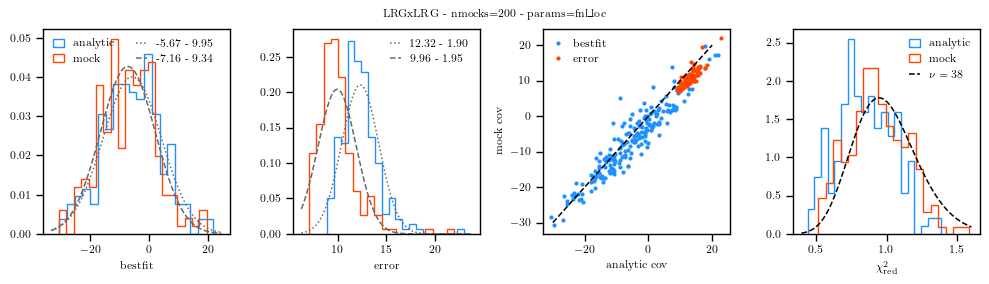

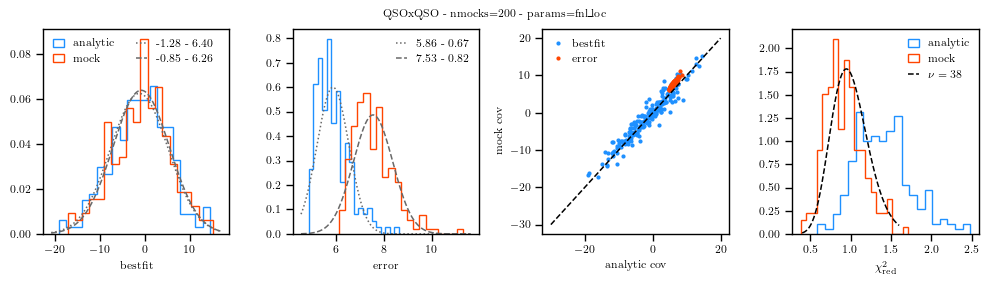

KeyError: 'LRGxQSO'

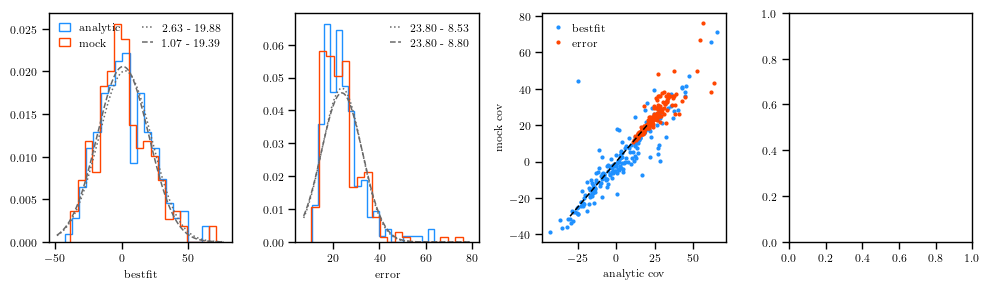

In [28]:
from scipy.stats import norm, chi2

if True:
    pdf_path = Path('fig/fit_individual_mocks_aladr1.pdf')

    only_fnl = True

    kmin = 1e-3

    tracers = ['LRGxLRG', 'QSOxQSO', 'LRGxQSO', 'ELGxELG', 'LRGxELG', 'ELGxQSO']

    with PdfPages(pdf_path) as pdf:
        for tracer in tracers:
            prof = profiles[tracer]
            for j in range(1 if only_fnl else 4):
                plt.figure(figsize=(10, 3))
                plt.subplot(141)
                plt.hist([float(prof['analytical_cov'][kmin]['_aladr1'][i][j][2]) for i in range(nmocks)], histtype='step', bins=20, density=True, label='analytic')
                plt.hist([float(prof['mock_cov'][kmin]['_aladr1'][i][j][2]) for i in range(nmocks)], histtype='step', bins=20, density=True, label='mock')
                xmin, xmax = plt.xlim()
                x = np.linspace(xmin, xmax, 1000)
                mu, std = norm.fit([float(prof['analytical_cov'][kmin]['_aladr1'][i][j][2]) for i in range(nmocks)])
                plt.plot(x, norm.pdf(x, mu, std), c='dimgray', ls=':', label=f'{mu:2.2f} - {std:2.2f}')
                mu, std = norm.fit([float(prof['mock_cov'][kmin]['_aladr1'][i][j][2]) for i in range(nmocks)])
                plt.plot(x, norm.pdf(x, mu, std), c='dimgray', ls='--', label=f'{mu:2.2f} - {std:2.2f}')
                plt.legend(loc='upper left', ncol=2)
                plt.xlabel('bestfit')
                #if j == 0: plt.axvline(0, ls='--', c='k', alpha=0.5, zorder=0)
                plt.subplot(142)
                plt.hist([float(prof['analytical_cov'][kmin]['_aladr1'][i][j][3]) for i in range(nmocks)], bins=20, density=True, histtype='step')
                plt.hist([float(prof['mock_cov'][kmin]['_aladr1'][i][j][3]) for i in range(nmocks)], bins=20, density=True, histtype='step')
                xmin, xmax = plt.xlim()
                x = np.linspace(xmin, xmax, 1000)
                mu, std = norm.fit([float(prof['analytical_cov'][kmin]['_aladr1'][i][j][3]) for i in range(nmocks)])
                plt.plot(x, norm.pdf(x, mu, std), c='dimgray', ls=':', label=f'{mu:2.2f} - {std:2.2f}')
                mu, std = norm.fit([float(prof['mock_cov'][kmin]['_aladr1'][i][j][3]) for i in range(nmocks)])
                plt.plot(x, norm.pdf(x, mu, std), c='dimgray', ls='--', label=f'{mu:2.2f} - {std:2.2f}')
                plt.legend()
                plt.xlabel('error')
                plt.subplot(143)
                plt.plot([float(prof['analytical_cov'][kmin]['_aladr1'][i][j][2]) for i in range(nmocks)], [float(prof['mock_cov'][kmin]['_aladr1'][i][j][2]) for i in range(nmocks)], ls='', marker='.', label='bestfit')
                plt.plot([float(prof['analytical_cov'][kmin]['_aladr1'][i][j][3]) for i in range(nmocks)], [float(prof['mock_cov'][kmin]['_aladr1'][i][j][3]) for i in range(nmocks)], ls='', marker='.', label='error')
                if j == 0: plt.plot([-30, 20], [-30, 20], ls='--', c='k')
                plt.xlabel('analytic cov')
                plt.ylabel('mock cov')
                plt.legend()
                plt.subplot(144)
                ndof = mocks[tracer][0].select(k=(kmin, 1)).size - 4
                plt.hist([-2*float(prof['analytical_cov'][kmin]['_aladr1'][i][4][2]) / ndof for i in range(nmocks)], histtype='step', bins=20, density=True, label='analytic')
                from lsstypes.utils import get_percival2014_factor
                percival = get_percival2014_factor(len(mocks['LRGxLRG']), ndof+4, 4) # don't forget to remove th percival factor when quoting the chi2 
                plt.hist([-2*float(prof['mock_cov'][kmin]['_aladr1'][i][4][2]) * percival / ndof for i in range(nmocks)], histtype='step', bins=20, density=True, label='mock')
                x = np.linspace(0.4, 1.6, 500)
                plt.plot(x, chi2.pdf(x, df=ndof, scale=1/ndof), label=fr'$\nu={ndof}$', ls='--', c='k')
                plt.legend()    
                plt.xlabel(r'$\chi^2_{\rm{red}}$')
                plt.suptitle(f"{tracer} - {nmocks=} - params={prof['analytical_cov'][kmin]['_aladr1'][0][j][0]}", fontsize=8, y=0.93)
                plt.tight_layout()
                pdf.savefig(plt.gcf())
                plt.show()
        
        pdf_path.resolve()

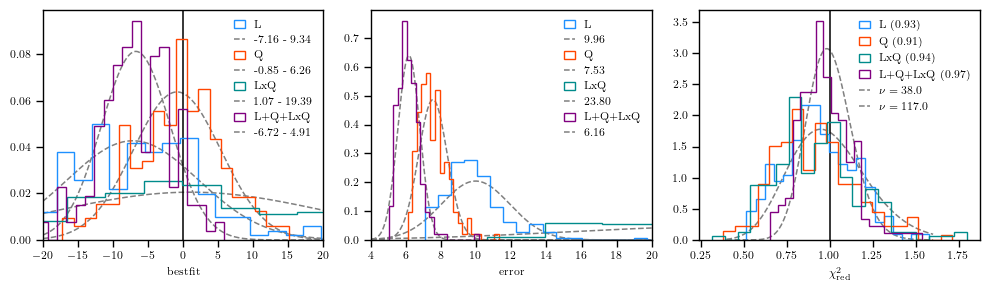

In [ ]:
from scipy.stats import norm, chi2

tracers_to_plot = ['LRGxLRG', 'QSOxQSO', 'LRGxQSO', 'LRGxLRG-LRGxQSO-QSOxQSO']

labels = {'LRGxLRG': 'L', 'QSOxQSO': 'Q', 'LRGxQSO': 'LxQ', 'LRGxLRG-LRGxQSO-QSOxQSO': 'L+Q+LxQ'}

kmin = 1e-3
extra_fn = '_aladr1'

plt.figure(figsize=(10, 3))
plt.subplot(131)
plt.xlim(-20,20)
for tracer in tracers_to_plot:
    prof = profiles[tracer]
    plt.hist([float(prof['mock_cov'][kmin][extra_fn][i][0][2]) for i in range(nmocks)], histtype='step', bins=20, density=True, label=labels[tracer])
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 1000)
    mu, std = norm.fit([float(prof['mock_cov'][kmin][extra_fn][i][0][2]) for i in range(nmocks)])
    plt.plot(x, norm.pdf(x, mu, std), c='gray', ls='--', label=f'{mu:2.2f} - {std:2.2f}', zorder=0)
plt.axvline(0, ls='-', c='k', alpha=1, zorder=0)
plt.legend(loc='upper right', ncol=1)
plt.xlabel('bestfit')

plt.subplot(132)
plt.xlim(4, 20)
for tracer in tracers_to_plot:
    prof = profiles[tracer]
    plt.hist([float(prof['mock_cov'][kmin][extra_fn][i][0][3]) for i in range(nmocks)], histtype='step', bins=20, density=True, label=labels[tracer])
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 1000)
    mu, std = norm.fit([float(prof['mock_cov'][kmin][extra_fn][i][0][3]) for i in range(nmocks)])
    plt.plot(x, norm.pdf(x, mu, std), c='gray', ls='--', label=f'{mu:2.2f}', zorder=0)
plt.legend(loc='upper right', ncol=1)
plt.xlabel('error')

plt.subplot(133)
ndofs = []
for tracer in tracers_to_plot:
    prof = profiles[tracer]
    idx_logpost = np.where(prof['mock_cov'][kmin][extra_fn][0][:,0] == 'logposterior')[0][0]
    nparams = float(np.sum(prof['mock_cov'][kmin][extra_fn][0][:,3] > ''))
    if "-" not in tracer:  
        nbins = mocks[tracer][0].select(k=(kmin, 1)).size    
    else:
        nbins = sum([mocks[tt][0].select(k=(kmin, 1)).size for tt in tracer.split("-")])
    ndof = nbins - nparams
    ndofs.append(ndof)

    from lsstypes.utils import get_percival2014_factor
    percival = get_percival2014_factor(len(mocks['LRGxLRG']), nbins, nparams)

    red_chi2 = [-2*float(prof['mock_cov'][kmin][extra_fn][i][idx_logpost][2]) * percival / ndof for i in range(nmocks)]

    plt.hist(red_chi2, histtype='step', bins=20, density=True, label=labels[tracer] + f' ({np.mean(red_chi2):.2f})')

for ndof in np.unique(ndofs):
    x = np.linspace(0.4, 1.6, 500)
    plt.plot(x, chi2.pdf(x, df=ndof, scale=1/ndof), label=fr'$\nu={ndof}$', ls='--', c='gray', zorder=0)
plt.axvline(1, ls='-', c='k', alpha=1, zorder=0)
plt.legend()    
plt.xlabel(r'$\chi^2_{\rm{red}}$')
plt.tight_layout()
plt.savefig(f'fig/fit_individual_mocks_png_{kmin}{extra_fn}.pdf')
plt.show()

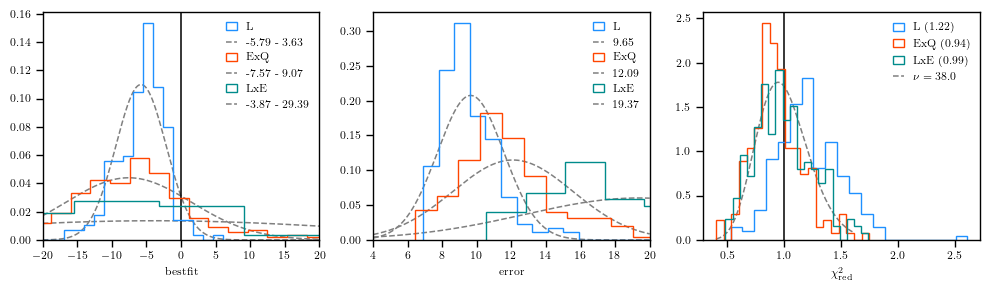

In [ ]:
from scipy.stats import norm, chi2

tracers_to_plot = ['ELGxELG', 'ELGxQSO', 'LRGxELG']

labels = {'ELGxELG': 'L', 'ELGxQSO': 'ExQ', 'LRGxELG': 'LxE'}

kmin = 1e-3
extra_fn = '_aladr1'

plt.figure(figsize=(10, 3))
plt.subplot(131)
plt.xlim(-20,20)
for tracer in tracers_to_plot:
    prof = profiles[tracer]
    plt.hist([float(prof['mock_cov'][kmin][extra_fn][i][0][2]) for i in range(nmocks)], histtype='step', bins=20, density=True, label=labels[tracer])
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 1000)
    mu, std = norm.fit([float(prof['mock_cov'][kmin][extra_fn][i][0][2]) for i in range(nmocks)])
    plt.plot(x, norm.pdf(x, mu, std), c='gray', ls='--', label=f'{mu:2.2f} - {std:2.2f}', zorder=0)
plt.axvline(0, ls='-', c='k', alpha=1, zorder=0)
plt.legend(loc='upper right', ncol=1)
plt.xlabel('bestfit')

plt.subplot(132)
plt.xlim(4, 20)
for tracer in tracers_to_plot:
    prof = profiles[tracer]
    plt.hist([float(prof['mock_cov'][kmin][extra_fn][i][0][3]) for i in range(nmocks)], histtype='step', bins=20, density=True, label=labels[tracer])
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 1000)
    mu, std = norm.fit([float(prof['mock_cov'][kmin][extra_fn][i][0][3]) for i in range(nmocks)])
    plt.plot(x, norm.pdf(x, mu, std), c='gray', ls='--', label=f'{mu:2.2f}', zorder=0)
plt.legend(loc='upper right', ncol=1)
plt.xlabel('error')

plt.subplot(133)
ndofs = []
for tracer in tracers_to_plot:
    prof = profiles[tracer]
    idx_logpost = np.where(prof['mock_cov'][kmin][extra_fn][0][:,0] == 'logposterior')[0][0]
    nparams = float(np.sum(prof['mock_cov'][kmin][extra_fn][0][:,3] > ''))
    if "-" not in tracer:  
        nbins = mocks[tracer][0].select(k=(kmin, 1)).size    
    else:
        nbins = sum([mocks[tt][0].select(k=(kmin, 1)).size for tt in tracer.split("-")])
    ndof = nbins - nparams
    ndofs.append(ndof)

    from lsstypes.utils import get_percival2014_factor
    percival = get_percival2014_factor(len(mocks['LRGxLRG']), nbins, nparams)

    red_chi2 = [-2*float(prof['mock_cov'][kmin][extra_fn][i][idx_logpost][2]) * percival / ndof for i in range(nmocks)]

    plt.hist(red_chi2, histtype='step', bins=20, density=True, label=labels[tracer] + f' ({np.mean(red_chi2):.2f})')

for ndof in np.unique(ndofs):
    x = np.linspace(0.4, 1.6, 500)
    plt.plot(x, chi2.pdf(x, df=ndof, scale=1/ndof), label=fr'$\nu={ndof}$', ls='--', c='gray', zorder=0)
plt.axvline(1, ls='-', c='k', alpha=1, zorder=0)
plt.legend()    
plt.xlabel(r'$\chi^2_{\rm{red}}$')
plt.tight_layout()
plt.savefig(f'fig/fit_individual_mocks_png_{kmin}{extra_fn}.pdf')
plt.show()

In [8]:
print(profiles['QSOxQSO']['mock_cov'][1e-3][''][0][0])
print(profiles['QSOxQSO']['mock_cov'][1e-3]['_aladr1'][0][0])

['fnl_loc' 'True' '-1.0246' '3.1306']
['fnl_loc' 'True' '-1.4626' '3.0243']


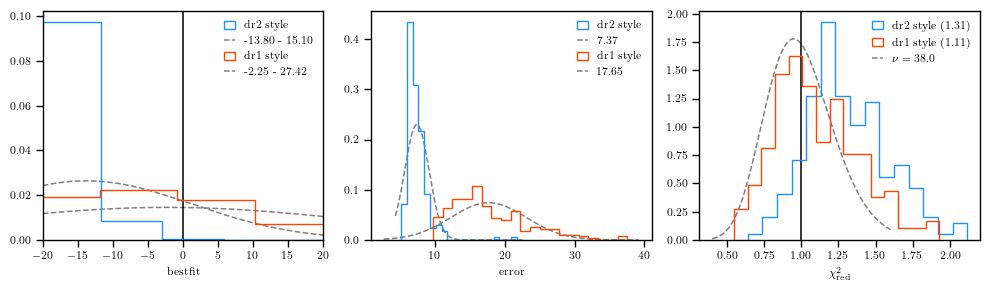

In [13]:
from scipy.stats import norm, chi2

kmin = 1e-3
nmocks = 200

tracer = 'LRGxELG'
#tracer = 'QSOxQSO'

labels = {'': 'dr2 style', '_aladr1': 'dr1 style'}

plt.figure(figsize=(10, 3))
plt.subplot(131)
plt.xlim(-20,20)
for extra_fn in ['', '_aladr1']:
    prof = profiles[tracer]
    plt.hist([float(prof['mock_cov'][kmin][extra_fn][i][0][2]) for i in range(nmocks)], histtype='step', bins=20, density=True, label=labels[extra_fn])
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 1000)
    mu, std = norm.fit([float(prof['mock_cov'][kmin][extra_fn][i][0][2]) for i in range(nmocks)])
    plt.plot(x, norm.pdf(x, mu, std), c='gray', ls='--', label=f'{mu:2.2f} - {std:2.2f}', zorder=0)
plt.axvline(0, ls='-', c='k', alpha=1, zorder=0)
plt.legend(loc='upper right', ncol=1)
plt.xlabel('bestfit')

plt.subplot(132)
#plt.xlim(4, 20)
for extra_fn in ['', '_aladr1']:
    prof = profiles[tracer]
    plt.hist([float(prof['mock_cov'][kmin][extra_fn][i][0][3]) for i in range(nmocks)], histtype='step', bins=20, density=True, label=labels[extra_fn])
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 1000)
    mu, std = norm.fit([float(prof['mock_cov'][kmin][extra_fn][i][0][3]) for i in range(nmocks)])
    plt.plot(x, norm.pdf(x, mu, std), c='gray', ls='--', label=f'{mu:2.2f}', zorder=0)
plt.legend(loc='upper right', ncol=1)
plt.xlabel('error')

plt.subplot(133)
ndofs = []
for extra_fn in ['', '_aladr1']:
    prof = profiles[tracer]
    idx_logpost = np.where(prof['mock_cov'][kmin][extra_fn][0][:,0] == 'logposterior')[0][0]
    nparams = float(np.sum(prof['mock_cov'][kmin][extra_fn][0][:,3] > ''))
    if "-" not in tracer:  
        nbins = mocks[tracer][0].select(k=(kmin, 1)).size    
    else:
        nbins = sum([mocks[tt][0].select(k=(kmin, 1)).size for tt in tracer.split("-")])
    ndof = nbins - nparams
    ndofs.append(ndof)

    from lsstypes.utils import get_percival2014_factor
    percival = get_percival2014_factor(len(mocks['LRGxLRG']), nbins, nparams)

    red_chi2 = [-2*float(prof['mock_cov'][kmin][extra_fn][i][idx_logpost][2]) * percival / ndof for i in range(nmocks)]

    plt.hist(red_chi2, histtype='step', bins=15, density=True, label=labels[extra_fn] + f' ({np.mean(red_chi2):.2f})')

for ndof in np.unique(ndofs):
    x = np.linspace(0.4, 1.6, 500)
    plt.plot(x, chi2.pdf(x, df=ndof, scale=1/ndof), label=fr'$\nu={ndof}$', ls='--', c='gray', zorder=0)

plt.axvline(1, ls='-', c='k', alpha=1, zorder=0)
plt.legend()    
plt.xlabel(r'$\chi^2_{\rm{red}}$')
plt.tight_layout()
plt.savefig(f'fig/fit_individual_mocks_RIC-AMR_comparison_{tracer}_{kmin}.pdf')
plt.show()